# Scenario A1: Single Supplier — No REC (Net Generators)

**Description:** Baseline scenario. Single supplier mandate where all consumers and
prosumers use ONE supplier (SUP_A / BG_A). No Renewable Energy Community structure.
Prosumers are modelled as **net generators** — only their RES output is billed;
local prosumer loads are excluded from settlement.

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 1 — SUP_A |
| Balancing Groups | 1 — BG_A (all 9 participants) |
| RECs | None |
| Prosumer type | **Net generator** (RES only, no local load) |
| Battery | None |

**Research role:** Pure baseline. All subsequent scenarios are compared against A1
to quantify the incremental effect of RECs, multiple suppliers, mixed prosumer
profiles, BG splitting, and battery storage.

**Comparison pairs:**
- A1 vs A1-mixed → effect of prosumer load inclusion on balancing costs
- A1 vs A2 → value of adding a REC under single-supplier mandate
- A1 vs B1 → effect of introducing a second independent supplier

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [1]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [2]:
CONFIG_FILE = "A1_single_supplier_no_rec.json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="A1")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts
2. **Intra-Day Market** - Adjust positions with updated ID forecasts  
3. **REC Settlement** - (Skipped for A1 - no REC configured)
4. **Balancing Market** - Settle imbalances at dual pricing
5. **Supplier Billing** - Calculate final costs per participant

In [3]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: A1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: A1
  System  : Single Supplier Mandate without REC - Scenario A1
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 1
  Prosumers    : 3
  Consumers    : 6
  RECs         : 0  →  has_rec = False
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 6)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 6)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (35136, 8)
✓ ID market : (35136, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: SKIPPED (no RECs in config)
✓ Balancing market: (35136, 27)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly aggregation: (12, 26)
✓ Profit/loss calculated

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for the supplier.

In [4]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – A1

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €      283.12
      Balancing Rewards   : €       71.15
      Retail Sales        : €   29,814.30
      ────────────────────────────────────────────
      Total Revenue       : €   30,168.57

    COSTS:
      Market Purchases    : €    3,463.56
      Balancing Penalties  : €       70.57
      Retail Purchases     : €    4,670.08
      ────────────────────────────────────────────
      Total Costs          : €    8,204.21

    PROFIT/LOSS:
      Annual Total         : €   21,964.36
      Monthly Average      : €    1,830.36

    IMBALANCE:
      System Position      : SHORT
      Total Imbalance      :         0.01 MWh
      BG Actual Position   :        91.65 MWh
      BG Forecast Position :        91.65 MWh



## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

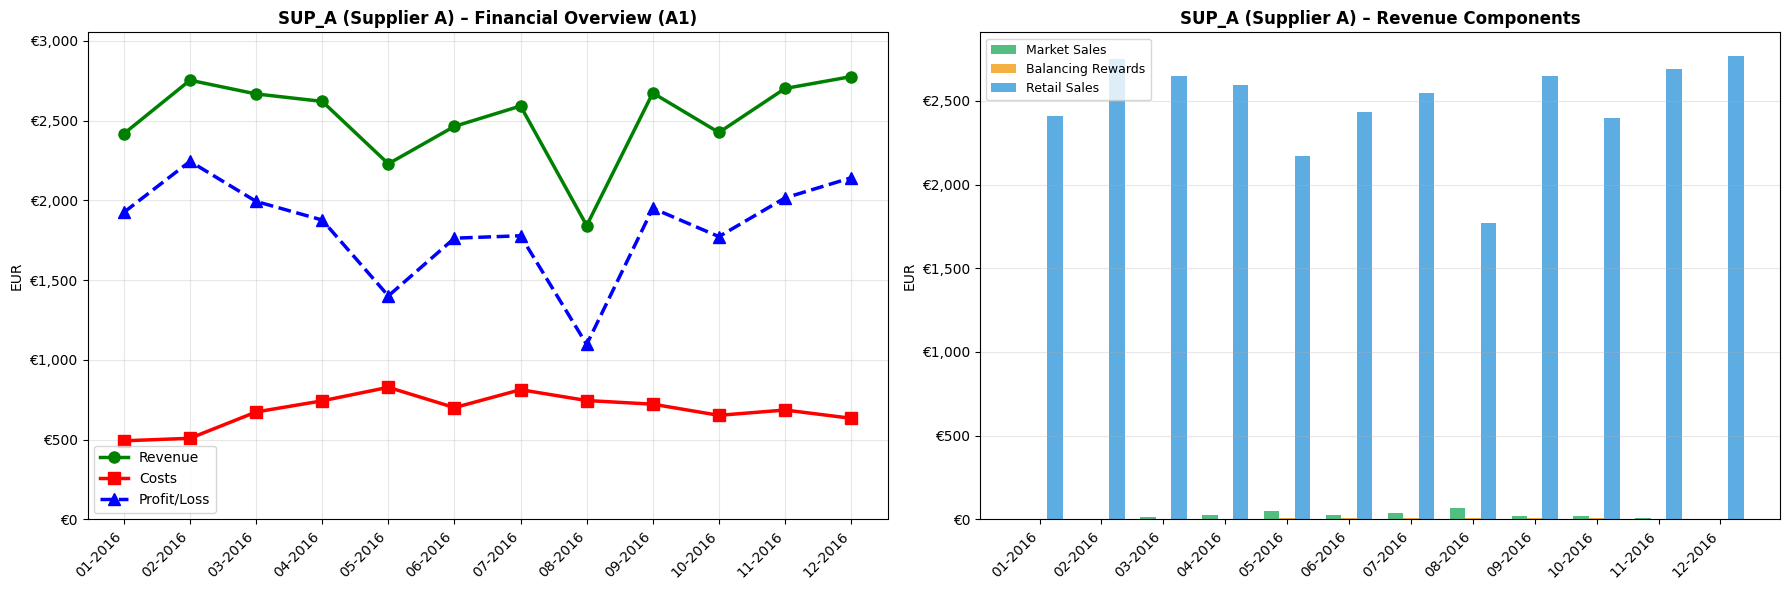

In [5]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

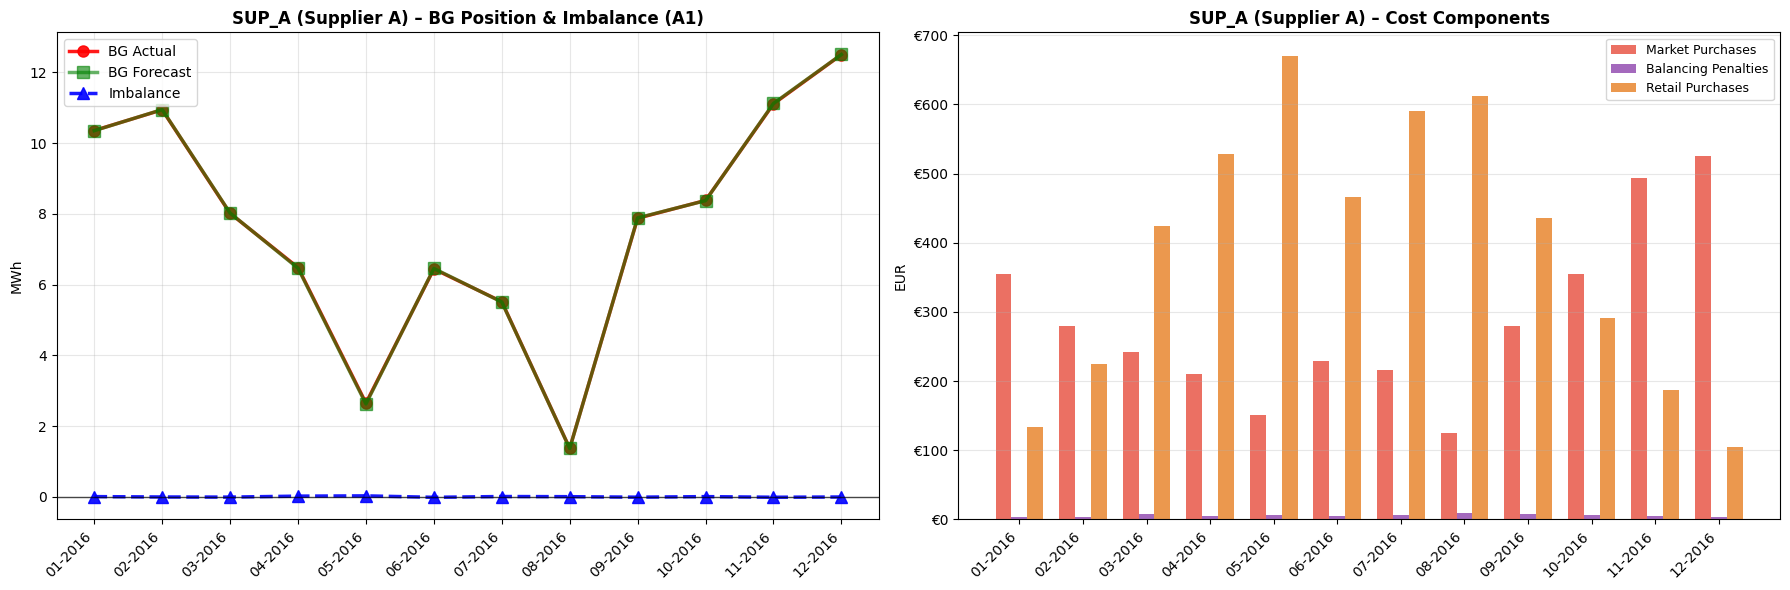

In [6]:
pipe.plot_imbalances()

## 7. Monthly Analysis Data
Display the detailed monthly analysis DataFrame with all financial metrics broken down by month.

In [7]:
pipe.es_monthly_analysis_df

,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,...,purchase_costs_eur,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,total_revenue_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_A,11.740290,0.180791,395.381203,4.664840,-1.175045,0.030932,29.579375,...,134.072290,5.529485,4.009907,2409.099920,2418.639312,355.532769,3.465164,134.072290,493.070224,1925.569088
1,02-2016,SUP_A,BG_A,12.437626,0.121162,314.480153,1.882415,-1.345223,0.021096,22.463459,...,224.344400,2.230811,4.371368,2747.154187,2753.756366,280.228549,4.270064,224.344400,508.843013,2244.913353
2,03-2016,SUP_A,BG_A,10.352735,1.026866,274.725242,15.168111,-1.208871,0.091983,24.094009,...,423.944189,17.181040,5.183383,2645.394321,2667.758744,242.508724,7.437098,423.944189,673.890011,1993.868733
3,04-2016,SUP_A,BG_A,8.797402,1.032603,241.398511,19.683030,-1.127719,0.173916,25.257687,...,528.246823,23.901538,5.622824,2591.454116,2620.978478,210.669928,4.842401,528.246823,743.759152,1877.219326
4,05-2016,SUP_A,BG_A,6.573481,2.838498,173.232440,44.972758,-0.817546,0.292393,22.993579,...,670.711583,51.825879,9.036340,2168.971492,2229.833712,151.316925,6.396274,670.711583,828.424782,1401.408930
5,06-2016,SUP_A,BG_A,8.714424,1.064149,260.907549,21.989673,-1.039799,0.152722,27.651608,...,466.291262,25.999581,6.102997,2432.454674,2464.557252,229.172007,5.689004,466.291262,701.152272,1763.404979
6,07-2016,SUP_A,BG_A,8.391116,1.604744,247.727572,31.466332,-1.056170,0.221446,27.138380,...,589.929932,37.108990,7.205016,2547.834860,2592.148866,216.402585,7.160590,589.929932,813.493108,1778.655759
7,08-2016,SUP_A,BG_A,4.780504,2.522270,142.692441,58.390462,-0.596044,0.295230,27.268374,...,612.143347,66.161635,7.847995,1768.591202,1842.600832,124.678803,8.750842,612.143347,745.572992,1097.027840
8,09-2016,SUP_A,BG_A,9.887178,0.704498,316.982297,17.102633,-1.173166,0.121973,30.137590,...,435.577534,20.628851,7.436418,2645.740784,2673.806054,279.304556,7.860264,435.577534,722.742354,1951.063699
9,10-2016,SUP_A,BG_A,10.156405,0.581479,398.922563,19.880555,-1.103117,0.095788,36.908256,...,291.957965,23.348741,6.078231,2396.744228,2426.171200,354.876465,6.015983,291.957965,652.850412,1773.320788


## 8. Customer Billing Summary
Display aggregated customer billing by customer type (consumer/prosumer).

In [8]:
pipe.customer_billing_df.groupby('customer_type').agg({
    'sales_revenue_eur': 'sum',
    'purchase_costs_eur': 'sum',
    'actual_load_mwh': 'sum',
    'actual_gen_mwh': 'sum'
})

,sales_revenue_eur,purchase_costs_eur,actual_load_mwh,actual_gen_mwh
customer_type,,,,
consumer,29814.300424,0.000000,148.329853,0.000000
prosumer,0.000000,4670.079182,0.000000,56.675718
